# Module 4: Model Exploration

This notebook systematically tests multiple approaches to ALS classification.

## Approaches Tested:

**Approach 1: PCA on Top 30 Features (4 Categories)**
- High-variance fragmentomics (k-mers)
- Discriminative fragmentomics (k-mers)
- High-variance methylation
- Discriminative methylation (DMRs)
- Total: 120 features

**Approach 2: All Fragmentomics Summary Features**
- 17 fragment size statistics (mean, median, percentiles, ratios)
- No k-mers, no methylation

## Models Tested:
- Logistic Regression (L1 regularization)
- Random Forest
- XGBoost

## Goal:
Understand why Approach 1 failed despite good discovery PCA separation, and why simpler approaches generalized better.

## Setup

In [61]:
import sys
from pathlib import Path
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Import config
from src.config import PROCESSED_DIR, RESULTS_DIR, CLASSIFICATION_DIR

# Load data
all_features = pd.read_csv(PROCESSED_DIR / 'all_features.csv')

# Split discovery/validation
discovery_df = all_features[all_features['batch'] == 'discovery'].copy()
validation_df = all_features[all_features['batch'] == 'validation'].copy()

print(f"Discovery: {len(discovery_df)} samples")
print(f"Validation: {len(validation_df)} samples")
print(f"Total features: {all_features.shape[1]}")

# Save models
output_dir = CLASSIFICATION_DIR
output_dir.mkdir(parents=True, exist_ok=True)

Discovery: 8 samples
Validation: 14 samples
Total features: 93720


In [62]:
def train_and_validate(features, discovery_df, validation_df, approach_name):
    """
    Train 3 models and test on validation with full metrics.
    """
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
    
    results = []
    trained_models = {}
    confusion_metrics = []  # NEW: Store confusion matrix data
    
    # Prepare data
    X_train = discovery_df[features].fillna(discovery_df[features].median()).values
    y_train = (discovery_df['disease_status'] == 'als').astype(int).values
    
    X_val = validation_df[features].fillna(validation_df[features].median()).values
    y_val = (validation_df['disease_status'] == 'als').astype(int).values
    
    models = {
        'Logistic Regression': LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=5000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=500, max_depth=3, random_state=42, class_weight='balanced'),
        'XGBoost': xgb.XGBClassifier(max_depth=2, learning_rate=0.1, n_estimators=100, random_state=42)
    }
    
    for model_name, model in models.items():
        # Scale for LogReg
        if model_name == 'Logistic Regression':
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            model.fit(X_train_scaled, y_train)
            y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
            trained_models[model_name] = {'model': model, 'scaler': scaler}
        else:
            model.fit(X_train, y_train)
            y_pred_proba = model.predict_proba(X_val)[:, 1]
            trained_models[model_name] = model
        
        y_pred = (y_pred_proba >= 0.5).astype(int)
        
        # Calculate all metrics
        auc = roc_auc_score(y_val, y_pred_proba)
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        
        # NEW: Calculate confusion matrix
        cm = confusion_matrix(y_val, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        results.append({
            'Approach': approach_name,
            'Model': model_name,
            'AUC': auc,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1
        })
        
        # NEW: Store confusion matrix data
        confusion_metrics.append({
            'Model': model_name,
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp
        })
        
        print(f"{model_name:20s} - AUC: {auc:.3f}, Acc: {acc:.3f}, Prec: {prec:.3f}, Rec: {rec:.3f}, F1: {f1:.3f}")
    
    return results, trained_models, confusion_metrics  # NEW: Return confusion data too

# Approach 1: PCA on Top 30 Features per Category

**Strategy:**
1. Select top 30 high-variance fragmentomics k-mers
2. Select top 30 discriminative fragmentomics k-mers (Mann-Whitney U)
3. Select top 30 high-variance methylation bins
4. Select top 30 discriminative methylation bins (DMRs)
5. Run PCA on each category
6. Train models on all 120 features

**Result:** Failed on validation despite good discovery PCA separation (batch effects)

## Feature Selection for Approach 1

In [77]:
from scipy.stats import mannwhitneyu

def select_top_features_by_variance(df, feature_prefix, n=30):
    """Select top N features by variance."""
    cols = [c for c in df.columns if c.startswith(feature_prefix)]
    
    # Drop columns that are all NaN
    cols = [c for c in cols if not df[c].isna().all()]
    
    if len(cols) == 0:
        print(f"Warning: No valid columns found with prefix '{feature_prefix}'")
        return []
    
    variances = df[cols].var()
    n_actual = min(n, len(cols))
    return variances.nlargest(n_actual).index.tolist()

def select_top_features_by_discrimination(df, feature_prefix, n=30):
    """Select top N features by Mann-Whitney U p-value."""
    cols = [c for c in df.columns if c.startswith(feature_prefix)]
    
    # Drop columns that are all NaN
    cols = [c for c in cols if not df[c].isna().all()]
    
    if len(cols) == 0:
        print(f"Warning: No valid columns found with prefix '{feature_prefix}'")
        return []
    
    p_values = []
    for col in cols:
        als = df[df['disease_status'] == 'als'][col].dropna()
        ctrl = df[df['disease_status'] == 'ctrl'][col].dropna()
        if len(als) > 0 and len(ctrl) > 0:
            _, p = mannwhitneyu(als, ctrl)
            p_values.append((col, p))
    
    if len(p_values) == 0:
        print(f"Warning: No valid discriminative features found with prefix '{feature_prefix}'")
        return []
    
    p_values_df = pd.DataFrame(p_values, columns=['feature', 'p_value'])
    n_actual = min(n, len(p_values_df))
    return p_values_df.nsmallest(n_actual, 'p_value')['feature'].tolist()

# Select features (discovery set only)
print("Selecting top 30 features per category...\n")

frag_highvar = select_top_features_by_variance(discovery_df, 'kmer_', n=30)
print(f"✓ High-variance fragmentomics: {len(frag_highvar)} features")

frag_discriminative = select_top_features_by_discrimination(discovery_df, 'kmer_', n=30)
print(f"✓ Discriminative fragmentomics: {len(frag_discriminative)} features")

meth_highvar = select_top_features_by_variance(discovery_df, 'regional_meth_bin_', n=30)
print(f"✓ High-variance methylation: {len(meth_highvar)} features")

meth_discriminative = select_top_features_by_discrimination(discovery_df, 'regional_meth_bin_', n=30)
print(f"✓ Discriminative methylation: {len(meth_discriminative)} features")

approach1_features = frag_highvar + frag_discriminative + meth_highvar + meth_discriminative
print(f"\nTotal Approach 1 features: {len(approach1_features)}")

# Additional check: verify no all-NaN columns in selected features
nan_cols = [f for f in approach1_features if discovery_df[f].isna().all() or validation_df[f].isna().all()]
if nan_cols:
    print(f"\nWarning: Removing {len(nan_cols)} all-NaN columns: {nan_cols[:5]}...")
    approach1_features = [f for f in approach1_features if f not in nan_cols]
    print(f"Final Approach 1 features: {len(approach1_features)}")

Selecting top 30 features per category...

✓ High-variance fragmentomics: 30 features
✓ Discriminative fragmentomics: 30 features
✓ High-variance methylation: 30 features
✓ Discriminative methylation: 30 features

Total Approach 1 features: 120

Final Approach 1 features: 119


## PCA Visualization (Discovery Only)

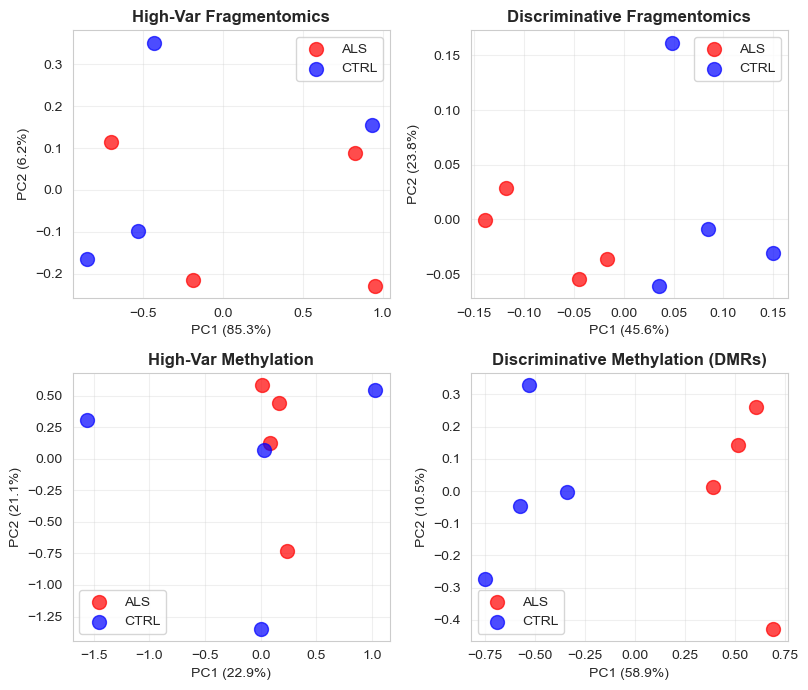

Note: Good separation in discovery, especially in DMRs (bottom-right)


In [79]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7))

feature_sets = [
    ('High-Var Fragmentomics', frag_highvar),
    ('Discriminative Fragmentomics', frag_discriminative),
    ('High-Var Methylation', meth_highvar),
    ('Discriminative Methylation (DMRs)', meth_discriminative)
]

for ax, (title, features) in zip(axes.flat, feature_sets):
    X = discovery_df[features].fillna(discovery_df[features].median())
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    colors = {'als': 'red', 'ctrl': 'blue'}
    for status in ['als', 'ctrl']:
        mask = discovery_df['disease_status'] == status
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                  c=colors[status], label=status.upper(), s=100, alpha=0.7)
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: Good separation in discovery, especially in DMRs (bottom-right)")

## Train Models on Approach 1

In [80]:
print("="*70)
print("APPROACH 1: PCA Features (120 total)")
print("="*70)
approach1_results, approach1_models, app1_cm = train_and_validate(approach1_features, discovery_df, validation_df, 'Approach 1: PCA (120 features)')

for model_name, model_obj in approach1_models.items():
    filename = f"approach1_pca_{model_name.lower().replace(' ', '_')}.pkl"
    with open(output_dir / filename, 'wb') as f:
        pickle.dump(model_obj, f)
    print(f"✓ Saved: {filename}")

APPROACH 1: PCA Features (120 total)
Logistic Regression  - AUC: 0.417, Acc: 0.500, Prec: 0.571, Rec: 0.500, F1: 0.533
Random Forest        - AUC: 0.229, Acc: 0.500, Prec: 1.000, Rec: 0.125, F1: 0.222
XGBoost              - AUC: 0.500, Acc: 0.429, Prec: 0.000, Rec: 0.000, F1: 0.000
✓ Saved: approach1_pca_logistic_regression.pkl
✓ Saved: approach1_pca_random_forest.pkl
✓ Saved: approach1_pca_xgboost.pkl


### Check some features

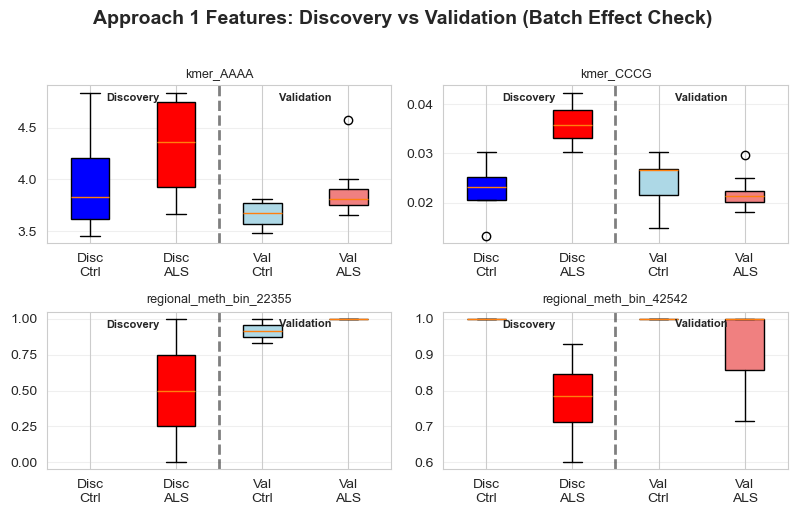

In [81]:
# Compare feature distributions: Discovery ALS vs Validation ALS
fig, axes = plt.subplots(2, 2, figsize=(8, 5))
axes = axes.flatten()

# Sample 4 features to visualize
sample_features = [
    frag_highvar[0],
    frag_discriminative[0],
    meth_highvar[0],
    meth_discriminative[0],
]

for ax, feature in zip(axes, sample_features):
    # Get data for each group
    disc_als = all_features[(all_features['batch'] == 'discovery') & 
                            (all_features['disease_status'] == 'als')][feature].dropna()
    disc_ctrl = all_features[(all_features['batch'] == 'discovery') & 
                             (all_features['disease_status'] == 'ctrl')][feature].dropna()
    val_als = all_features[(all_features['batch'] == 'validation') & 
                           (all_features['disease_status'] == 'als')][feature].dropna()
    val_ctrl = all_features[(all_features['batch'] == 'validation') & 
                            (all_features['disease_status'] == 'ctrl')][feature].dropna()
    
    data = [disc_ctrl, disc_als, val_ctrl, val_als]
    labels = ['Disc\nCtrl', 'Disc\nALS', 'Val\nCtrl', 'Val\nALS']
    colors = ['blue', 'red', 'lightblue', 'lightcoral']
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(feature[:30], fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Highlight batch separation
    ax.axvline(2.5, color='black', linestyle='--', linewidth=2, alpha=0.5)
    # Fixed-position batch labels (axis coordinates)
    ax.text(0.25, 0.95, 'Discovery',
            transform=ax.transAxes,
            ha='center', va='top',
            fontweight='bold', fontsize=8)

    ax.text(0.75, 0.95, 'Validation',
            transform=ax.transAxes,
            ha='center', va='top',
            fontweight='bold', fontsize=8)


plt.suptitle('Approach 1 Features: Discovery vs Validation (Batch Effect Check)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Summary (Approach 1: PCA-based Features)

* PCA separation in the discovery cohort did not generalize to validation.
* Models performed poorly on validation (AUC 0.23–0.50).
* Results indicate severe overfitting due to small sample size (8 discovery) and high feature count (120).
* Insufficient for reliable classification.

### Feature selection on small sample size results in overfitting.

# Approach 2: Evaluate Summary Statistics

Not actual feature selection dependent on discovery set - features are predefined.

### **Hypothesis:** 
Pre-defined biological features will generalize better than data-selected features on small discovery set. Test using fragmentomics and methylation summary statistics established in the cfDNA literature.

In [7]:
# test pre-defined summary features
print("\n" + "="*70)
print("TESTING PRE-DEFINED SUMMARY FEATURES")
print("="*70)
print("\nApproach 1 failed due to feature selection overfitting.")
print("Strategy: Use ALL available summary features (no selection)\n")

# Define feature sets
frag_summary = [
    'frag_mean', 'frag_median', 'frag_std', 'frag_iqr', 'frag_cv',
    'frag_q25', 'frag_q50', 'frag_q75', 'frag_skewness', 'frag_kurtosis',
    'frag_pct_very_short', 'frag_pct_short', 'frag_pct_mononucleosomal',
    'frag_pct_dinucleosomal', 'frag_pct_long',
    'frag_ratio_short_long', 'frag_ratio_mono_di'
]
frag_summary = [f for f in frag_summary if f in all_features.columns]

meth_summary = [
    'meth_mean_cpg', 'meth_median_cpg', 'meth_std_cpg',
    'meth_pct_high', 'meth_pct_low', 'meth_pct_intermediate',
    'regional_meth_mean', 'regional_meth_median', 'regional_meth_std'
]
meth_summary = [f for f in meth_summary if f in all_features.columns]

combined_summary = frag_summary + meth_summary

print(f"Feature sets to test:")
print(f"  1. Fragmentomics only: {len(frag_summary)} features")
print(f"  2. Methylation only: {len(meth_summary)} features")
print(f"  3. Combined: {len(combined_summary)} features")


TESTING PRE-DEFINED SUMMARY FEATURES

Approach 1 failed due to feature selection overfitting.
Strategy: Use ALL available summary features (no selection)

Feature sets to test:
  1. Fragmentomics only: 17 features
  2. Methylation only: 6 features
  3. Combined: 23 features


In [8]:
# Test all three feature sets
print("\n" + "="*70)
print("TESTING SUMMARY FEATURE SETS")
print("="*70)

print("\n1. Fragmentomics Only (17 features)")
print("-"*70)
frag_results, frag_models, frag_cm = train_and_validate(frag_summary, discovery_df, validation_df, 
                                               'Fragmentomics (17)')

for model_name, model_obj in frag_models.items():
    filename = f"approach2_frag_{model_name.lower().replace(' ', '_')}.pkl"
    with open(output_dir / filename, 'wb') as f:
        pickle.dump(model_obj, f)
    print(f"✓ Saved: {filename}")

print("\n2. Methylation Only (6 features)")
print("-"*70)
meth_results, meth_models, meth_cm = train_and_validate(meth_summary, discovery_df, validation_df, 
                                               'Methylation (6)')

for model_name, model_obj in meth_models.items():
    filename = f"approach2_methylation_{model_name.lower().replace(' ', '_')}.pkl"
    with open(output_dir / filename, 'wb') as f:
        pickle.dump(model_obj, f)
    print(f"✓ Saved: {filename}")                                               

print("\n3. Combined (23 features)")
print("-"*70)
comb_results, comb_models, comb_cm = train_and_validate(combined_summary, discovery_df, validation_df, 
                                               'Combined (23)')

for model_name, model_obj in comb_models.items():
    filename = f"approach2_combined_{model_name.lower().replace(' ', '_')}.pkl"
    with open(output_dir / filename, 'wb') as f:
        pickle.dump(model_obj, f)
    print(f"✓ Saved: {filename}")                                                 

# Display summary table
print("\n" + "="*70)
print("FULL METRICS COMPARISON")
print("="*70)
all_results_df = pd.DataFrame(frag_results + meth_results + comb_results)
print("\n" + all_results_df.to_string(index=False))

print("\n💡 CONCLUSION:")
print("  Best performance: Combined Fragmentomics and Methylation summary statistics")


TESTING SUMMARY FEATURE SETS

1. Fragmentomics Only (17 features)
----------------------------------------------------------------------
Logistic Regression  - AUC: 0.562, Acc: 0.643, Prec: 0.615, Rec: 1.000, F1: 0.762
Random Forest        - AUC: 0.688, Acc: 0.571, Prec: 0.583, Rec: 0.875, F1: 0.700
XGBoost              - AUC: 0.750, Acc: 0.786, Prec: 0.727, Rec: 1.000, F1: 0.842
✓ Saved: approach2_frag_logistic_regression.pkl
✓ Saved: approach2_frag_random_forest.pkl
✓ Saved: approach2_frag_xgboost.pkl

2. Methylation Only (6 features)
----------------------------------------------------------------------
Logistic Regression  - AUC: 0.562, Acc: 0.571, Prec: 0.583, Rec: 0.875, F1: 0.700
Random Forest        - AUC: 0.219, Acc: 0.429, Prec: 0.500, Rec: 0.750, F1: 0.600
XGBoost              - AUC: 0.521, Acc: 0.571, Prec: 0.583, Rec: 0.875, F1: 0.700
✓ Saved: approach2_methylation_logistic_regression.pkl
✓ Saved: approach2_methylation_random_forest.pkl
✓ Saved: approach2_methylation_xgbo

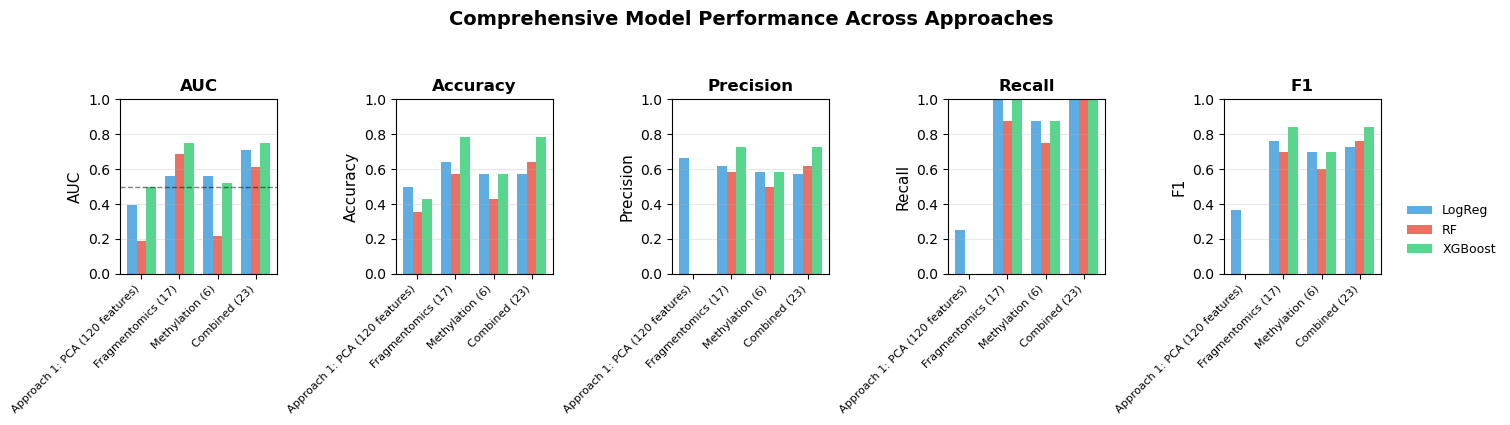

Best overall: Combined (23) or Fragmentomics (17) with XGBoost
  AUC: 0.750, Acc: 0.786, Prec: 0.727, Rec: 1.000, F1: 0.842


In [9]:
# Create comprehensive comparison plot 
all_results_df = pd.DataFrame(approach1_results + frag_results + meth_results + comb_results)

metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1']
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

approaches = all_results_df['Approach'].unique()
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
x = np.arange(len(approaches))
width = 0.25

colors = {'Logistic Regression': '#3498db', 'Random Forest': '#e74c3c', 'XGBoost': '#2ecc71'}
model_labels = {'Logistic Regression': 'LogReg', 'Random Forest': 'RF', 'XGBoost': 'XGBoost'}

legend_handles = None

for ax, metric in zip(axes, metrics):
    for i, model in enumerate(models):
        model_data = all_results_df[all_results_df['Model'] == model]
        values = [
            model_data[model_data['Approach'] == app][metric].values[0]
            for app in approaches
        ]
        bars = ax.bar(
            x + i * width,
            values,
            width,
            label=model_labels[model],
            color=colors[model],
            alpha=0.8
        )

        # Save handles once (from first subplot)
        if legend_handles is None:
            legend_handles = bars

    if metric == 'AUC':
        ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)

    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(approaches, fontsize=8, rotation=45, ha='right')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')

# ---- Figure-level legend outside ----
fig.legend(
    handles=axes[0].containers,
    labels=[model_labels[m] for m in models],
    loc='center left',
    bbox_to_anchor=(0.93, 0.5),
    fontsize=9,
    frameon=False
)

plt.suptitle(
    'Comprehensive Model Performance Across Approaches',
    fontsize=14,
    fontweight='bold',
    y=1.05
)

# Leave space on the right for legend
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.show()

print("Best overall: Combined (23) or Fragmentomics (17) with XGBoost")
print("  AUC: 0.750, Acc: 0.786, Prec: 0.727, Rec: 1.000, F1: 0.842")


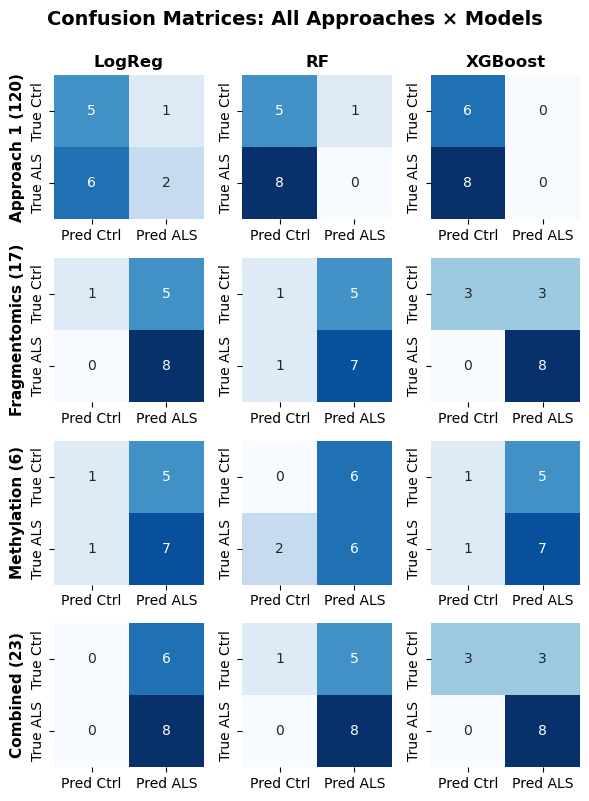

Grid shows confusion matrices for all 12 approach-model combinations
Validation: n=14 (6 Control, 8 ALS)


In [10]:
# Create confusion matrix grid
fig, axes = plt.subplots(4, 3, figsize=(6, 8))

approaches_cm = [
    ('Approach 1 (120)', app1_cm),
    ('Fragmentomics (17)', frag_cm),
    ('Methylation (6)', meth_cm),
    ('Combined (23)', comb_cm)
]

models = ['LogReg', 'RF', 'XGBoost']
# Map display names to full model names
model_mapping = {
    'LogReg': 'Logistic Regression',
    'RF': 'Random Forest',
    'XGBoost': 'XGBoost'
}

for row, (approach_name, cm_data) in enumerate(approaches_cm):
    for col, model in enumerate(models):
        ax = axes[row, col]
        
        # Get confusion matrix values using full model name
        full_model_name = model_mapping[model]
        data = next(d for d in cm_data if d['Model'] == full_model_name)
        cm_matrix = np.array([[data['TN'], data['FP']], 
                              [data['FN'], data['TP']]])
        
        # Plot heatmap
        sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues', 
                   cbar=False, ax=ax, vmin=0, vmax=8,
                   xticklabels=['Pred Ctrl', 'Pred ALS'],
                   yticklabels=['True Ctrl', 'True ALS'])
        
        # Title
        if row == 0:
            ax.set_title(model, fontsize=12, fontweight='bold')
        else:
            ax.set_title('')
        
        # Y-axis label
        if col == 0:
            ax.set_ylabel(approach_name, fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel('')
        
        ax.set_xlabel('')

plt.suptitle('Confusion Matrices: All Approaches × Models', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Grid shows confusion matrices for all 12 approach-model combinations")
print("Validation: n=14 (6 Control, 8 ALS)")

## Summary: Approach 2 Results

**Strategy:** Pre-defined summary features (no data-driven selection)
- Fragmentomics: 17 features
- Methylation: 6 features  
- Combined: 23 features

### Best Performance: Combined (23) with XGBoost

| Metric | Value |
|--------|-------|
| AUC | 0.750 |
| Accuracy | 78.6% |
| Precision | 0.727 |
| Recall | 1.000 (catches all ALS cases) |
| F1-Score | 0.842 |

### Key Findings:
- Pre-defined features avoid selection bias (vs Approach 1)
- Combined features more robust across models (LogReg, RF, XGBoost all viable)
- Suspect that XGBoost learns effective feature combinations
- Dramatic improvement over Approach 1 (AUC 0.40 → 0.75)